# Exploring 90K Spotify Tracks: What Actually Makes a Song Popular?

A quick dig through Spotify's audio features dataset; danceability, energy, tempo and more across 114,000 tracks spanning 114 genres. Mostly curious whether any of the "obvious" audio features (energy, danceability, tempo) actually correlate with popularity or whether it's mostly down to who the artist is.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"] = "#161b22"
plt.rcParams["axes.edgecolor"] = "#30363d"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["text.color"] = "white"
plt.rcParams["xtick.color"] = "#8b949e"
plt.rcParams["ytick.color"] = "#8b949e"
plt.rcParams["axes.titlecolor"] = "white"
plt.rcParams["grid.color"] = "#21262d"

df = pd.read_csv("/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv")
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna(subset=["artists", "album_name", "track_name"])

print(f"{len(df):,} rows loaded")
df.head()

113,999 rows loaded


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## First things first, a quirk worth flagging

Same track can appear multiple times under different genre tags (e.g. one song listed as both "acoustic" and "j-pop"). Not an error, genuinely how Spotify categorizes crossover tracks. Keeping this in mind: full rows for genre-level questions, deduped for anything about individual songs.

In [2]:
df_by_genre = df.copy()
df_unique = df.drop_duplicates(subset="track_id", keep="first").copy()

print(f"Genre-tagged rows: {len(df_by_genre):,}")
print(f"Unique tracks: {len(df_unique):,}")

Genre-tagged rows: 113,999
Unique tracks: 89,740


## What does "popularity" even look like here?

Before comparing genres or audio features, worth seeing the shape of the target variable itself. Spotify's popularity score runs 0-100 and it's not obvious upfront whether most songs cluster in the middle, skew low or pile up at the extremes.

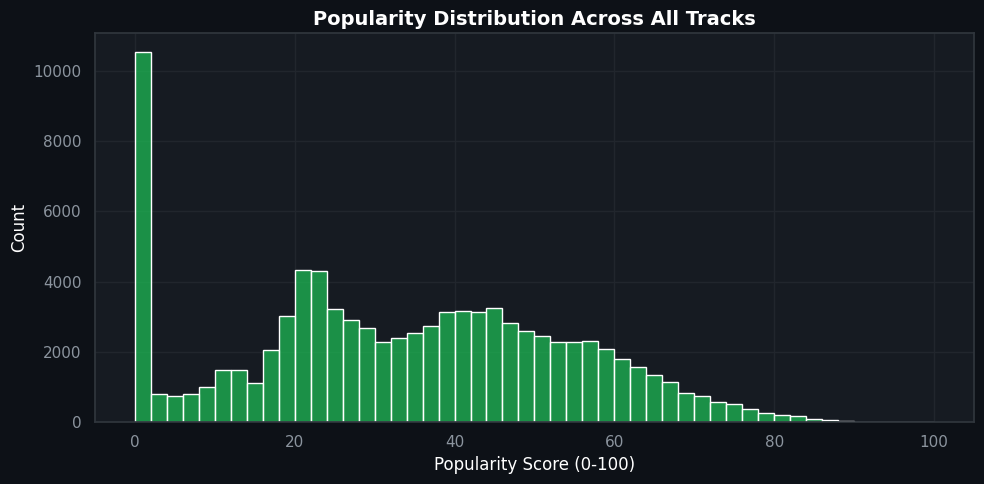

count    89740.000000
mean        33.198808
std         20.580640
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64

Tracks with popularity = 0: 9447


In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df_unique["popularity"], bins=50, color="#1DB954")
plt.title("Popularity Distribution Across All Tracks", fontsize=14, fontweight="bold")
plt.xlabel("Popularity Score (0-100)")
plt.tight_layout()
plt.show()

print(df_unique["popularity"].describe())
print("\nTracks with popularity = 0:", (df_unique["popularity"] == 0).sum())

### A big chunk of tracks sit at exactly zero

9,447 tracks (10.5%) have a popularity score of exactly 0 way too many to be a coincidence of naturally low scores. This is almost certainly Spotify's algorithm not having enough play/stream data yet to assign a real score, rather than 89K genuine "nobody likes this song" verdicts. Worth keeping in mind for anything we build later these zeros could quietly drag down averages or mislead a model into thinking "obscure artist" and "unscored track" are the same thing.

Otherwise the distribution looks like a fairly reasonable spread centered in the 20-50 range, which tracks with most songs on Spotify being decently mainstream but not viral hits.

## Do audio features actually predict popularity or is it mostly noise?

Danceability, energy, tempo, Spotify computes all of these per track. Worth checking directly whether any of them meaningfully correlate with popularity, rather than assuming "more energetic = more popular" or similar intuitive guesses.

loudness            0.071674
danceability        0.064275
energy              0.013725
tempo               0.007280
valence            -0.011508
liveness           -0.013857
acousticness       -0.038828
speechiness        -0.047086
instrumentalness   -0.127477
Name: popularity, dtype: float64


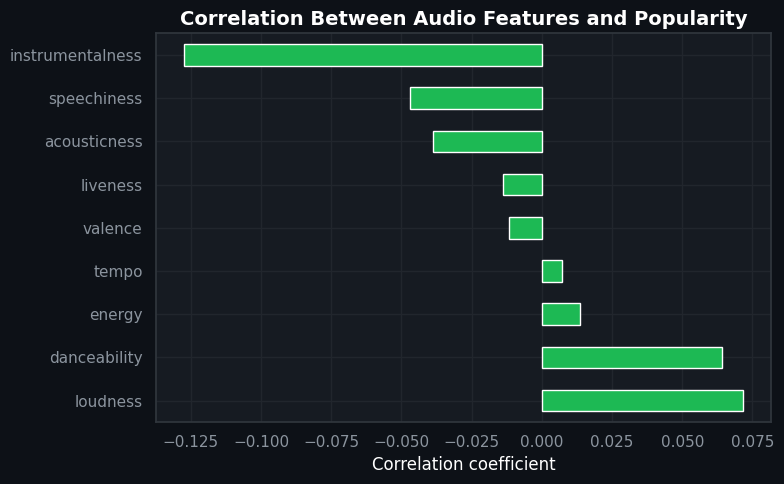

In [4]:
audio_features = ["danceability", "energy", "loudness", "speechiness", 
                   "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

corr_with_pop = df_unique[audio_features + ["popularity"]].corr()["popularity"].drop("popularity").sort_values(ascending=False)
print(corr_with_pop)

plt.figure(figsize=(8, 5))
corr_with_pop.plot(kind="barh", color="#1DB954")
plt.title("Correlation Between Audio Features and Popularity", fontsize=14, fontweight="bold")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

### None of it matters much, audio features barely correlate with popularity

Every correlation here is weak. The strongest, `instrumentalness` at -0.127, still only explains a tiny fraction of the variance in popularity and even that's a fairly intuitive one (instrumental tracks skew less mainstream than vocal tracks, which matches common sense). Loudness and danceability, the two features you'd most expect to matter for "catchy pop hit" intuition, barely register at 0.07 and 0.06.

This is a genuinely useful negative result: **a song's sonic characteristics alone tell you almost nothing about how popular it'll become.** Popularity is far more likely driven by factors this dataset doesn't capture at all, artist fame, marketing spend, playlist placement, release timing, TikTok virality and so on. It's a good reminder that "the data available" and "the data that actually explains the outcome" are often very different things.

## If audio features don't predict popularity, do they at least differ meaningfully by genre?

Even if these features can't predict popularity, they should still meaningfully separate genres that's kind of the whole point of a genre. Worth checking a few obvious contrasts (e.g. acoustic vs. EDM) to sanity-check the data makes sense before going further.

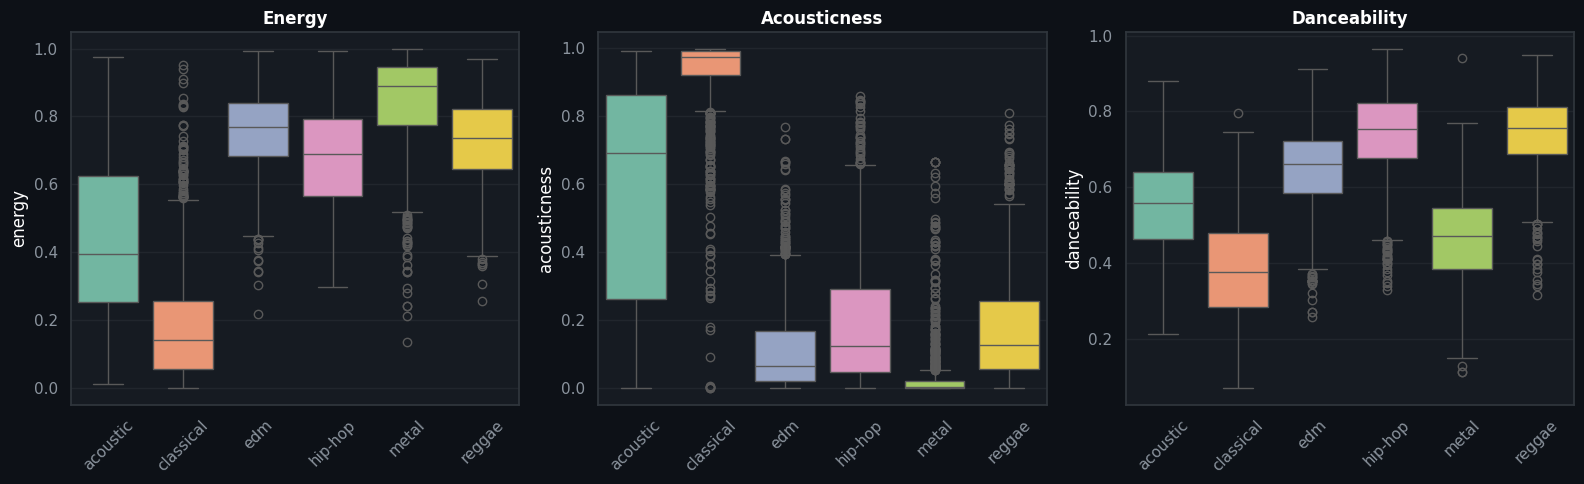

In [5]:
genres_to_compare = ["acoustic", "edm", "classical", "hip-hop", "metal", "reggae"]
subset = df_by_genre[df_by_genre["track_genre"].isin(genres_to_compare)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, ["energy", "acousticness", "danceability"]):
    sns.boxplot(data=subset, x="track_genre", y=feature, hue="track_genre", 
                palette="Set2", legend=False, ax=ax)
    ax.set_title(feature.capitalize(), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Genres separate cleanly and exactly as expected

- **Energy**: Metal and EDM sit at the top (~0.75-0.9), classical sits lowest by a wide margin (~0.15), acoustic is broad and middling, makes total sense
- **Acousticness**: Classical is almost entirely maxed out (~0.95+), while metal is pinned near zero, about as clean a genre signature as you could hope for
- **Danceability**: Hip-hop and reggae lead comfortably (~0.75), classical trails behind (~0.4), also matches intuition

This is a nice sanity check: even though these audio features told us almost nothing about popularity, they clearly *do* capture real, meaningful differences in how genres actually sound. The dataset is trustworthy, it's just answering a different question than "what makes something popular."

## Which genres are actually the most popular, on average?

Sonic character aside, worth checking directly which genres tend to have the highest average popularity scores and whether that lines up with mainstream intuition.

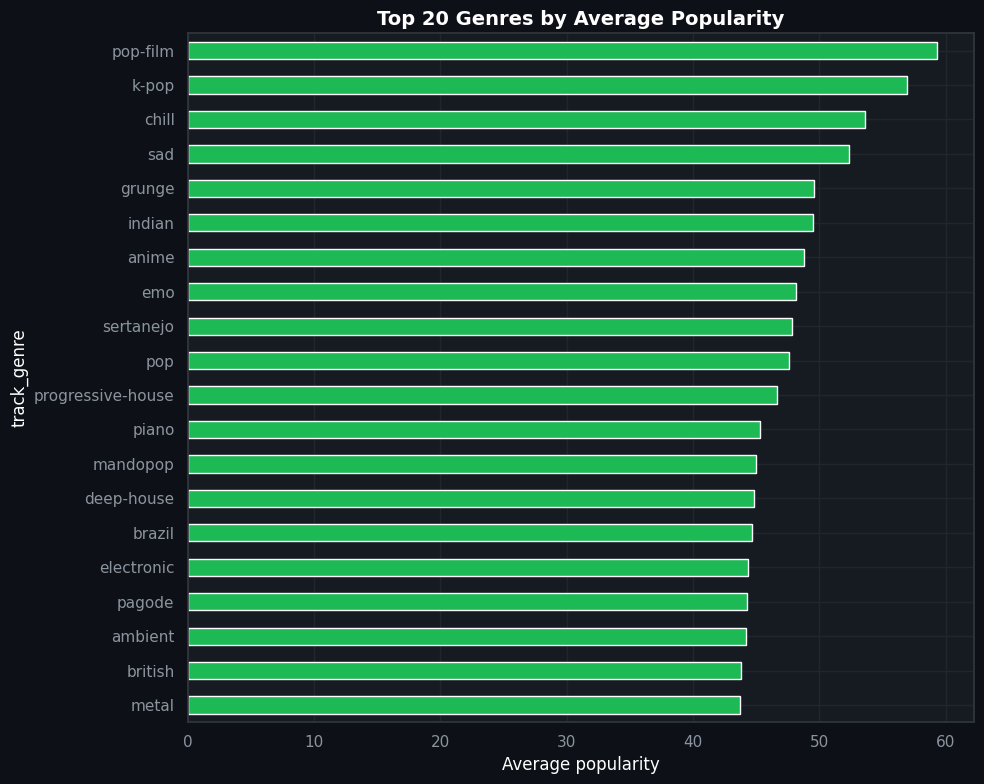

track_genre
pop-film     59.283000
k-pop        56.952953
chill        53.651000
sad          52.379000
grunge       49.594000
indian       49.539000
anime        48.772000
emo          48.128000
sertanejo    47.866000
pop          47.576000
Name: popularity, dtype: float64

Lowest 5:
 track_genre
chicago-house     12.339
detroit-techno    11.174
latin              8.297
romance            3.245
iranian            2.210
Name: popularity, dtype: float64


In [6]:
genre_popularity = df_by_genre.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
genre_popularity.head(20).plot(kind="barh", color="#1DB954")
plt.title("Top 20 Genres by Average Popularity", fontsize=14, fontweight="bold")
plt.xlabel("Average popularity")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(genre_popularity.head(10))
print("\nLowest 5:\n", genre_popularity.tail(5))

### Some expected winners and a couple of real surprises

**Top genres** — pop-film, k-pop, chill, sad and pop itself land near the top, which broadly matches mainstream intuition (pop-adjacent and algorithmically-favored mood playlists tend to rack up plays). K-pop's strong showing reflects its genuinely massive global streaming numbers in recent years.

**But the bottom is the more interesting story.** Chicago-house, Detroit-techno and latin scoring at the very bottom (8-12) is surprising — latin music is enormously popular globally, so seeing it near the floor here likely says more about **how this specific dataset was sampled** than about latin music's actual popularity. This is worth being upfront about rather than treating the ranking as gospel: genre popularity here reflects whichever specific tracks got included under each genre tag, not a true global genre popularity ranking.

**"Romance" and "iranian" scoring near zero (3.2 and 2.2)** likely reflects small, niche catalogs within this dataset rather than genuine unpopularity — a good reminder to check genre sample sizes before trusting an average.

In [7]:
genre_counts = df_by_genre["track_genre"].value_counts()
low_genres = ["romance", "iranian", "latin", "chicago-house", "detroit-techno"]
print(genre_counts[low_genres])

track_genre
romance           1000
iranian           1000
latin             1000
chicago-house     1000
detroit-techno    1000
Name: count, dtype: int64


### Correction: it's not a sample size issue after all

Every genre in this dataset has exactly 1,000 tracks — including "romance," "latin," and "iranian." So the low popularity scores for these genres aren't due to small, unrepresentative samples; the dataset was deliberately balanced with equal tracks per genre.

This actually makes the low rankings more genuinely puzzling. The most likely explanation: **whoever curated this dataset selected specific tracks for each genre tag and that selection may not reflect each genre's real-world mainstream popularity** — e.g. the 1,000 "latin" tracks pulled into this dataset might be a narrower or more niche slice of the genre than the enormous mainstream latin pop hits that dominate global streaming charts.

**Honest takeaway**: genre-level popularity comparisons in this dataset say more about *which specific tracks got selected under each label* than about how popular each genre truly is worldwide. Worth treating any genre ranking here as a property of this dataset's curation, not a global truth — a good general lesson for any dataset with equal-sized categories that seem to defy real-world intuition.

## Can we predict a track's genre from its audio features alone?

Unlike popularity (which barely correlated with anything), genre showed clean, visible separation in the boxplots earlier. Worth testing formally: can a model actually classify genre using nothing but the audio features?

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

genre_subset = ["classical", "metal", "hip-hop", "acoustic", "edm", "reggae"]
genre_df = df_by_genre[df_by_genre["track_genre"].isin(genre_subset)].copy()

features = ["danceability", "energy", "loudness", "speechiness", 
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

X = genre_df[features]
y = genre_df["track_genre"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {len(X_train):,} rows, testing on {len(X_test):,} rows")
print(y_train.value_counts())

Training on 4,800 rows, testing on 1,200 rows
track_genre
acoustic     800
reggae       800
classical    800
metal        800
edm          800
hip-hop      800
Name: count, dtype: int64


In [9]:
clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print(f"Overall accuracy: {accuracy_score(y_test, preds):.3f}")
print("\n", classification_report(y_test, preds))

Overall accuracy: 0.747

               precision    recall  f1-score   support

    acoustic       0.72      0.74      0.73       200
   classical       0.94      0.91      0.92       200
         edm       0.68      0.79      0.73       200
     hip-hop       0.64      0.55      0.59       200
       metal       0.84      0.83      0.84       200
      reggae       0.66      0.66      0.66       200

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



### 75% accuracy across 6 genres — and this time it's a meaningful number

With balanced classes (200 per genre in the test set), a random guess would score ~17%, so 75% overall accuracy reflects real, substantial signal — audio features genuinely do predict genre well.

**But it's not uniform across genres:**
- **Classical (0.94 precision, 0.91 recall)** — by far the easiest to identify. Matches the boxplots exactly: classical's acousticness and energy profiles were the most extreme and distinct of any genre.
- **Metal (0.84 / 0.83)** — also strongly separable, likely driven by its distinctively high energy and low acousticness.
- **Hip-hop (0.64 / 0.55)** — the weakest performer. Makes sense: hip-hop shares danceability and energy ranges with both reggae and EDM, so the model struggles to draw a clean boundary using only these 9 features.
- **Reggae (0.66 / 0.66)** and **EDM (0.68 / 0.79)** — middling, likely confused with each other and with hip-hop for similar reasons.

**Takeaway**: genre classification works well specifically for genres with distinctive, extreme audio profiles (classical, metal) and struggles most for genres that overlap in danceability/energy/tempo space (hip-hop, reggae, EDM) — a good illustration of how a model's performance directly reflects how separable the underlying classes actually are in feature space, not just how "different" they sound to a human ear.

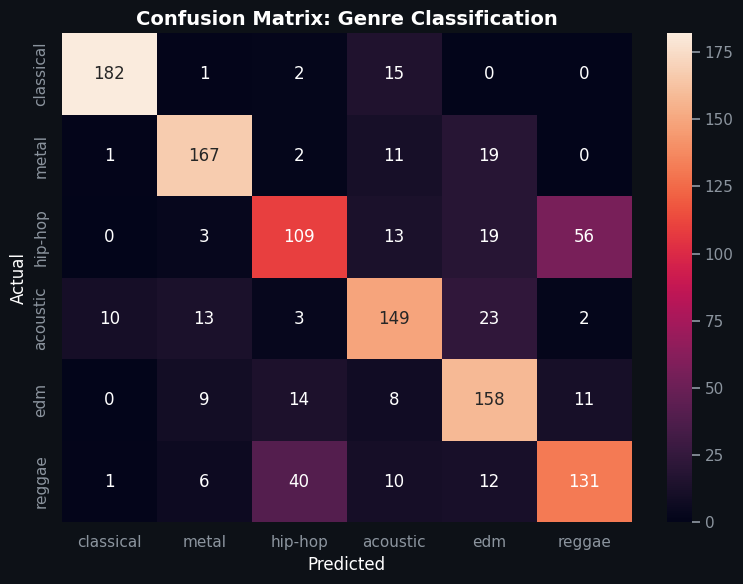

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds, labels=genre_subset)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="rocket", xticklabels=genre_subset, yticklabels=genre_subset)
plt.title("Confusion Matrix: Genre Classification", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Scaling up: can we classify all 114 genres, not just 6?

The 6-genre test showed real signal, especially for sonically distinct genres. Let's see how a stronger model handles the full complexity of all 114 genres at once — a much harder problem, since many genres inevitably overlap in sound.

In [11]:
from sklearn.preprocessing import LabelEncoder

X_full = df_by_genre[features]
y_full = df_by_genre["track_genre"]

le = LabelEncoder()
y_full_encoded = le.fit_transform(y_full)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full_encoded, test_size=0.2, random_state=42, stratify=y_full_encoded)

print(f"Training on {len(X_train_f):,} rows across {len(le.classes_)} genres")

Training on 91,199 rows across 114 genres


In [12]:
clf_full = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
clf_full.fit(X_train_f, y_train_f)
preds_f = clf_full.predict(X_test_f)

acc_full = accuracy_score(y_test_f, preds_f)
print(f"Overall accuracy across 114 genres: {acc_full:.3f}")
print(f"(Random guessing baseline would be roughly {1/114:.3f})")

Overall accuracy across 114 genres: 0.225
(Random guessing baseline would be roughly 0.009)


### 22.5% accuracy across 114 genres — much lower, but genuinely meaningful

Compared to random guessing (~0.9%), the model is roughly **25x better than chance** — real signal clearly persists even at this scale. But it's a huge drop from the 75% we saw with just 6 well-separated genres.

**This makes complete sense rather than signaling a broken model.** With only 6 genres, we deliberately picked sonically distinct ones (classical vs metal vs hip-hop). With all 114, the dataset includes countless closely related sub-genres — house, deep-house, progressive-house, techno and detroit-techno, for example, likely share nearly identical danceability/energy/tempo profiles, making them genuinely indistinguishable using only these 9 audio features. No model could cleanly separate genres that are, acoustically, nearly the same thing.

**The real lesson**: classification difficulty scales with how many *genuinely overlapping* categories you ask a model to separate — not just how many categories there are. Audio features alone can roughly place a song in the right neighborhood (rock-adjacent vs electronic-adjacent vs acoustic-adjacent), but can't reliably pinpoint fine-grained sub-genre distinctions that even humans might disagree on.

In [13]:
y_test_labels = le.inverse_transform(y_test_f)
pred_labels = le.inverse_transform(preds_f)

errors = pd.DataFrame({"actual": y_test_labels, "predicted": pred_labels})
errors_only = errors[errors["actual"] != errors["predicted"]]

print(errors_only.groupby(["actual", "predicted"]).size().sort_values(ascending=False).head(15))

actual             predicted        
dub                dubstep              97
reggae             reggaeton            88
techno             minimal-techno       85
latino             reggaeton            84
songwriter         singer-songwriter    80
edm                house                76
dubstep            dub                  67
samba              pagode               62
singer-songwriter  songwriter           58
punk               punk-rock            56
dancehall          j-dance              54
reggaeton          latino               53
latin              reggaeton            52
chill              sad                  52
punk-rock          punk                 51
dtype: int64


### The model's mistakes make complete sense

Every single top confusion pair is between genuinely related, closely overlapping genres:
- **dub ↔ dubstep**, **techno ↔ minimal-techno**, **punk ↔ punk-rock**, 
  **singer-songwriter ↔ songwriter** — these are essentially sub-genre variants of the same broader style, not unrelated categories
- **reggae → reggaeton**, **latino → reggaeton**, **latin → reggaeton** — reggaeton is a genuine fusion genre sitting at the intersection of Latin and reggae influences, so confusion here reflects a real musical relationship, not a modeling failure
- **edm → house** — house is a sub-genre of EDM broadly, so this is arguably not even a "wrong" answer so much as a hierarchy mismatch in how the dataset labeled genres

**Zero nonsensical confusions appear in the top 15** — no classical mistaken for death-metal, no confusion between wildly different sound profiles. This confirms the 22.5% accuracy number reflects a model that's making *musically sensible* mistakes, confusing genres that arguably overlap in real listening experience, not one that's failing to learn anything meaningful.

**A nice implication**: this dataset's 114 "genres" aren't 114 independent categories — many are closely nested sub-genres of a smaller set of true parent genres (house family, techno family, punk family, Latin family, singer-songwriter family). A model predicting the *parent* genre would likely perform dramatically better than one predicting the specific sub-genre label.

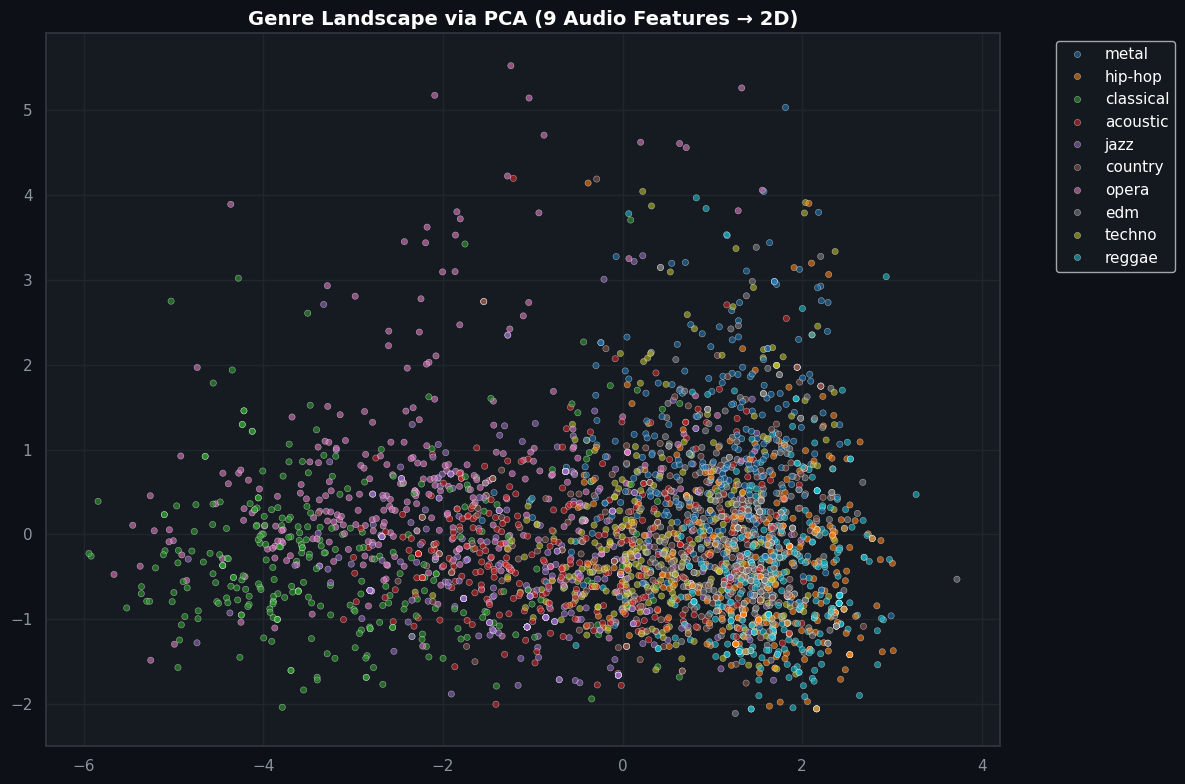

Variance explained by 2 components: 51.2%


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sample = df_by_genre[df_by_genre["track_genre"].isin(
    ["classical", "metal", "hip-hop", "acoustic", "edm", "reggae", "jazz", "country", "techno", "opera"]
)].sample(3000, random_state=42)

scaled = StandardScaler().fit_transform(sample[features])
pca = PCA(n_components=2)
coords_pca = pca.fit_transform(scaled)

plt.figure(figsize=(12, 8), facecolor="#0d1117")
sns.scatterplot(x=coords_pca[:,0], y=coords_pca[:,1], hue=sample["track_genre"].values, 
                palette="tab10", alpha=0.6, s=20)
plt.title("Genre Landscape via PCA (9 Audio Features → 2D)", fontsize=14, fontweight="bold")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

### The genre landscape is a gradient, not distinct islands

A few things stand out:

- **Classical and opera occupy their own space on the left edge**, clearly separated from everything else — consistent with the boxplots earlier showing classical's extreme acousticness and low energy. Opera sits nearby but with more vertical spread, suggesting more internal variation (some quiet, some dramatically loud).
- **Metal, hip-hop, techno, edm and reggae mostly overlap into one dense central blob** on the right side — this matches exactly what the confusion matrix and 114-genre classification already told us: these genres share a lot of common ground in danceability/energy/loudness space, so there's no clean visual boundary between them either.
- **Jazz, acoustic and country sit in the middle-left**, forming a loose bridge between the classical/opera cluster and the dense modern-genre blob — sonically, this makes sense as these are often more "organic"/acoustic-leaning genres without being as extreme as classical.

**The honest takeaway**: genre isn't really 10 (or 114) discrete sonic categories — it's more like a continuous gradient from "quiet/acoustic/classical" to "loud/dense/electronic," with most modern genres clustered tightly together in the "loud" end of that spectrum. This is a good visual confirmation of the same conclusion the classification experiments already pointed to.

**One honest caveat**: these 2 components only capture 51.2% of the total variance across the original 9 audio features — meaning roughly half the real information is lost in this compression. The overlapping blob in the middle might partly reflect genuine sonic similarity between metal/hip-hop/edm/techno/reggae, but it could also partly be an artifact of forcing 9 dimensions down into just 2. The classical/opera separation on the left is likely trustworthy either way, since it showed up consistently across the boxplots, classification results, *and* this PCA — but the blurriness in the "modern genre" cluster should be read as suggestive, not definitive.

## A simple "songs like this" recommender

Using cosine similarity across the same 9 audio features, we can find tracks that sound most similar to any given song — a simplified version of what a real content-based recommendation engine does under the hood.

In [15]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
feature_matrix = scaler.fit_transform(df_unique[features])

def recommend_similar(track_name, n=5):
    matches = df_unique[df_unique["track_name"].str.lower() == track_name.lower()]
    
    if matches.empty:
        print(f"'{track_name}' not found — try another track name")
        return None
    
    row_position = df_unique.index.get_loc(matches.index[0])
    
    sim_scores = cosine_similarity([feature_matrix[row_position]], feature_matrix)[0]
    top_idx = sim_scores.argsort()[::-1][1:n+1]
    
    result = df_unique.iloc[top_idx][["track_name", "artists", "track_genre", "popularity"]].copy()
    result["similarity"] = sim_scores[top_idx].round(3)
    return result

recommend_similar("Comedy")

,track_name,artists,track_genre,popularity,similarity
111951,Skylight,Gramatik,trip-hop,45,0.954
357,Look For The Good (Single Version),Jason Mraz,acoustic,21,0.932
92863,That Certain Female,Charlie Feathers,rockabilly,46,0.932
28341,Monde de fous,Danakil,dub,32,0.932
39173,Blink 182,Trille,german,53,0.928


### Sensible-ish, but reveals a real limitation of pure audio-feature similarity

"Comedy" is a mellow, acoustic-leaning track by Gen Hoshino. The recommendations share a similarly relaxed organic feel — trip-hop, acoustic, rockabilly, dub and a German track all land in a broadly "chill, mid-tempo, non-electronic" neighborhood, which is a reasonable match on vibe.

But notice the **genre labels are all different** — none of the top 5 matches share the original "acoustic" tag. This exposes a real limitation: **cosine similarity on these 9 audio features finds songs with similar *measurable sonic properties*, not songs that a human would necessarily call similar.** A track like "Blink 182" by an artist called Trille (not the actual band) shows up here purely because its danceability/energy/valence numbers happen to align — genre labels, lyrical content, cultural context and "vibe" in the fuller sense aren't captured by these 9 features at all.

**This is an honest limitation to state plainly**: a real production recommender system (like Spotify's actual one) uses far more signals — listening history, collaborative filtering, playlist co-occurrence, lyrics, cultural/scene context — precisely because raw audio features alone, as shown here, only get you partway to genuinely good recommendations.

In [16]:
recommend_similar("Ghost - Acoustic")

,track_name,artists,track_genre,popularity,similarity
93923,Моя душечка,Oleg Pogudin,romance,0,0.996
108598,Viejo Ciego (feat. Antonio Agri & Esteban Morg...,Roberto Goyeneche;Antonio Agri;Esteban Morgado,tango,19,0.995
76293,"Carmen, Act II: No.15 Quintette : Nous avons e...",Georges Bizet;Nicolas Rivenq;Michel Plasson;Wo...,opera,26,0.995
8133,"Bewitched, Bothered, And Bewildered - Stereo V...",Ella Fitzgerald,blues,0,0.994
8084,"Bewitched, Bothered, And Bewildered - Stereo V...",Ella Fitzgerald,blues,0,0.994


### This one holds together much better

"Ghost - Acoustic" is a quiet, sparse, acoustic ballad — and every single recommendation fits that same mold: Russian romance, tango, an opera aria and two Ella Fitzgerald blues standards. All slow, intimate, largely acoustic/orchestral pieces with similar loudness and energy profiles, even though the genre labels span five completely different categories (romance, tango, opera, blues).

**Two things worth noting:**
1. This is actually a good illustration of the recommender doing exactly what it's built to do — find similar *sound*, regardless of genre label. A quiet acoustic ballad and a quiet opera aria genuinely can sound more alike to a feature-based model than two songs both labeled "acoustic" but with different tempos/energy.
2. Three of the five recommendations have a **popularity score of 0** — a reminder of the placeholder-zero issue flagged earlier in the notebook. The similarity engine has no concept of popularity at all; it will happily recommend an unscored, possibly obscure track alongside a well-known one, which is worth being aware of if this were ever used in a real product.

**Overall conclusion on the recommender**: audio-feature similarity captures mood and sonic texture reasonably well — quiet/sparse tracks find other quiet/sparse tracks — but it explicitly ignores genre, cultural context and popularity. It's a legitimate building block for a real recommender, but not a complete one on its own.

## Summary of the ML exploration

- **Genre classification (6 genres)**: 75% accuracy — audio features cleanly separate sonically distinct genres like classical and metal.
- **Genre classification (114 genres)**: Dropped to 22.5% accuracy, but ~25x better than chance. Confusion matrix showed the model's mistakes were musically sensible (dub↔dubstep, reggae↔reggaeton), revealing that many "genres" are really nested sub-genre families rather than independent categories.
- **PCA genre landscape**: Visually confirmed the same story — classical/opera stand apart, while modern genres (metal, hip-hop, edm, techno, reggae) blur together in one dense cluster, consistent with the classification confusion patterns.
- **Content-based recommender**: Cosine similarity on audio features finds tracks with genuinely similar sound/mood, but explicitly ignores genre label and popularity — useful as one signal among many, not a complete recommendation system by itself.

Across every experiment, the same theme emerged from a different angle each time: **these 9 audio features capture real, meaningful structure in how music sounds, but they map only loosely onto the genre labels and popularity metrics humans actually care about.**